# Visualization - Approach B: Angle Detection

This notebook visualizes the model's orientation predictions and and the ground truth orientation arrows.

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
import torchvision 
from PIL import Image
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import json

## Configuration

In [ ]:
DATA_DIR      = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/dataset')
PROCESSED_DIR = DATA_DIR / 'processed'
LABELS_DIR    = PROCESSED_DIR / 'labels_keypoints'
GT_EXPORT     = DATA_DIR / 'ground_truth' / 'labels' / 'all_annotations_merged.json'
MODEL_PATH = Path('/home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/models/best_keypoint_model_B.pth')

# test split
TEST_IMG = DATA_DIR / 'images' / 'test'
TEST_LABELS = LABELS_DIR / 'test'

# device and hyperparameters
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 256
BATCH_SIZE = 16

## Load Model

In [4]:
HEAD_LABEL = 'Head'
TAIL_LABEL = 'Tail'

# model definition
class KeypointModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.mobilenet_v3_small(weights='IMAGENET1K_V1')
        self.backbone.classifier = nn.Sequential(
            nn.Linear(576, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)   # sin, cos
        )

    def forward(self, x):
        return self.backbone(x)

# load model
print("\nLoading model...")
model = KeypointModel().to(DEVICE)
if MODEL_PATH.exists():
    model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
    print(f"Loaded model from {MODEL_PATH}")
else:
    print(f"No saved model found at {MODEL_PATH}")

model.eval()


Loading model...


Loaded model from /home/azureuser/cloudfiles/code/Users/s2410929002/CVI_2026_GroupProject/models/best_keypoint_model.pth


KeypointModel(
  (backbone): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )
          (2): C

## Load Ground Truth

In [5]:
# load GT annotations from Label Studio export
def load_ground_truth(gt_export_path):
    if not gt_export_path.exists():
        print(f"ERROR: GT file not found: {gt_export_path}")
        return {}

    with open(gt_export_path) as f:
        data = json.load(f)

    gt = {}
    for item in data:
        img_name = Path(item.get('data', {}).get('img', item.get('file_upload', ''))).stem.split('-', 1)[-1]

        pairs = []
        for ann in item['annotations']:
            pending_head = None
            all_tails = [
                (r['value']['x'] / 100.0, r['value']['y'] / 100.0)
                for r in ann['result']
                if r['value']['keypointlabels'][0] == 'Tail'
            ]

            for r in ann['result']:
                label = r['value']['keypointlabels'][0]
                x = r['value']['x'] / 100.0
                y = r['value']['y'] / 100.0

                if label == 'Head':
                    pending_head = (x, y)
                elif label == 'Tail' and pending_head is not None:
                    pairs.append({'Head': pending_head, 'Tail': (x, y)})
                    pending_head = None

            # if a head had no following tail, pair by nearest remaining tail
            if pending_head is not None:
                used_tails = {p['Tail'] for p in pairs}
                remaining = [t for t in all_tails if t not in used_tails]
                if remaining:
                    best = min(remaining,
                               key=lambda t: (pending_head[0]-t[0])**2 + (pending_head[1]-t[1])**2)
                    pairs.append({'Head': pending_head, 'Tail': best})

        if pairs:
            gt[img_name] = pairs

    print(f"Loaded {len(gt)} images with GT annotations")
    print(f"Total annotated animals: {sum(len(p) for p in gt.values())}")
    return gt

gt = load_ground_truth(GT_EXPORT)
gt_lookup = gt

Loaded 154 images with GT annotations
Total annotated animals: 360


## Load YOLO Boxes


In [6]:
# load bbox annotations from label files and compute crops
def load_all_bboxes(label_path):
    bboxes = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            bboxes.append({
                'line': line.strip(),
                'cx': float(parts[1]),
                'cy': float(parts[2]),
                'bw': float(parts[3]),
                'bh': float(parts[4]),
            })
    return bboxes

# compute pixel crop coords for a bbox dict
def compute_crop(bbox, orig_w, orig_h, pad=0.5, min_frac=0.10):
    cx, cy = bbox['cx'], bbox['cy']
    bw, bh = bbox['bw'], bbox['bh']

    x1 = max(0.0, (cx - bw/2 - bw*pad)) * orig_w
    y1 = max(0.0, (cy - bh/2 - bh*pad)) * orig_h
    x2 = min(1.0, (cx + bw/2 + bw*pad)) * orig_w
    y2 = min(1.0, (cy + bh/2 + bh*pad)) * orig_h

    min_crop_px = orig_w * min_frac
    if (x2 - x1) < min_crop_px:
        mid_x = (x1 + x2) / 2
        x1 = max(0, mid_x - min_crop_px / 2)
        x2 = min(orig_w, mid_x + min_crop_px / 2)

    min_crop_py = orig_h * min_frac
    if (y2 - y1) < min_crop_py:
        mid_y = (y1 + y2) / 2
        y1 = max(0, mid_y - min_crop_py / 2)
        y2 = min(orig_h, mid_y + min_crop_py / 2)

    return x1, y1, x2, y2

# match predicted keypoints to GT pairs by nearest midpoint distance
def match_predictions_to_gt(predictions, gt_pairs):
    matched = []
    used_gt = set()
    for pred in predictions:
        pred_mid = np.array([
            (pred['pred_head'][0] + pred['pred_tail'][0]) / 2,
            (pred['pred_head'][1] + pred['pred_tail'][1]) / 2,
        ])
        best_dist, best_idx = float('inf'), None
        for i, gt_pair in enumerate(gt_pairs):
            if i in used_gt:
                continue
            gt_mid = np.array([
                (gt_pair['Head'][0] + gt_pair['Tail'][0]) / 2,
                (gt_pair['Head'][1] + gt_pair['Tail'][1]) / 2,
            ])
            d = np.linalg.norm(pred_mid - gt_mid)
            if d < best_dist:
                best_dist, best_idx = d, i
        if best_idx is not None:
            matched.append((pred, gt_pairs[best_idx]))
            used_gt.add(best_idx)
        else:
            matched.append((pred, None))
    return matched

In [7]:
def find_best_bbox(label_path, ref_x, ref_y):
    """
    return the bbox line whose center is closest to (ref_x, ref_y)
    ref_x / ref_y are normalised [0,1] coordinates (e.g. midpoint of GT head+tail)
    """
    best_line, best_dist = None, float('inf')
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cx, cy = float(parts[1]), float(parts[2])
            d = np.sqrt((cx - ref_x) ** 2 + (cy - ref_y) ** 2)
            if d < best_dist:
                best_dist = d
                best_line = line.strip()
    return best_line

#### Check test set for labels

In [8]:
test_images = sorted([f.stem for f in TEST_IMG.glob('*.jpg')])

labeled = []
for img_name in test_images:
    for split in ['test', 'val', 'train']:
        if (LABELS_DIR / split / f"{img_name}.txt").exists():
            labeled.append((img_name, split))
            break

print(f"Test images with labels: {len(labeled)} / {len(test_images)}")
for img_name, split in labeled[:20]:
    print(f"  {img_name}  (label in: {split})")

Test images with labels: 28 / 2483
  284_9347  (label in: train)
  284_9356  (label in: test)
  284_9363  (label in: val)
  284_9374  (label in: train)
  284_9375  (label in: test)
  284_9377  (label in: test)
  284_9406  (label in: train)
  284_9407  (label in: val)
  284_9467  (label in: test)
  284_9530  (label in: test)
  284_9545  (label in: test)
  284_9581  (label in: val)
  284_9633  (label in: test)
  284_9639  (label in: test)
  284_9652  (label in: val)
  284_9662  (label in: val)
  55_10008  (label in: train)
  55_10038  (label in: test)
  55_10078  (label in: test)
  55_10138  (label in: test)


## Visualization Function

In [13]:
# visualize predictions for a single image, showing all bbox crops and GT pairs
def visualize_prediction(image_name, img_split='test', show_ground_truth=True):
    img_path = DATA_DIR / 'images' / img_split / f"{image_name}.jpg"
    if not img_path.exists():
        print(f"Image not found: {img_path}")
        return None

    kp_label_path = None
    for split in ['test', 'val', 'train']:
        candidate = LABELS_DIR / split / f"{image_name}.txt"
        if candidate.exists():
            kp_label_path = candidate
            break
    if kp_label_path is None:
        print(f"No label found for {image_name}, skipping")
        return None

    img = Image.open(img_path).convert('RGB')
    orig_w, orig_h = img.size

    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    bboxes = load_all_bboxes(kp_label_path)
    if not bboxes:
        print(f"No bboxes found for {image_name}")
        return None

    # run model on every bbox - get angle per animal
    predictions = []
    for bbox in bboxes:
        x1, y1, x2, y2 = compute_crop(bbox, orig_w, orig_h)
        cx_px = bbox['cx'] * orig_w
        cy_px = bbox['cy'] * orig_h
        img_crop = img.crop((x1, y1, x2, y2))
        img_tensor = transform(img_crop).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            out = model(img_tensor).cpu().numpy()[0]
        angle = np.arctan2(out[0], out[1])
        arrow_len = max(bbox['bw'] * orig_w, bbox['bh'] * orig_h) * 1.5
        predictions.append({
            'cx': cx_px,
            'cy': cy_px,
            'angle': angle,
            'arrow_len': arrow_len,
        })

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(img)

    # draw all bboxes
    for bbox in bboxes:
        cx, cy = bbox['cx'] * orig_w, bbox['cy'] * orig_h
        bw, bh = bbox['bw'] * orig_w, bbox['bh'] * orig_h
        rect = plt.Rectangle((cx - bw/2, cy - bh/2), bw, bh,
                              fill=False, edgecolor='red', linewidth=1.5)
        ax.add_patch(rect)

    # draw GT arrows
    if show_ground_truth and image_name in gt_lookup:
        for i, pair in enumerate(gt_lookup[image_name]):
            gt_hx = pair['Head'][0] * orig_w
            gt_hy = pair['Head'][1] * orig_h
            gt_tx = pair['Tail'][0] * orig_w
            gt_ty = pair['Tail'][1] * orig_h
            label = 'GT orientation' if i == 0 else '_nolegend_'
            ax.annotate('', xy=(gt_hx, gt_hy), xytext=(gt_tx, gt_ty),
                        arrowprops=dict(arrowstyle='->', color='blue', lw=1,
                                        mutation_scale=10),
                        label=label)
            ax.plot(gt_hx, gt_hy, 'r^', markersize=4, alpha=0.9,
                    label='GT Head' if i == 0 else '_nolegend_')
            ax.plot(gt_tx, gt_ty, 'rs', markersize=4, alpha=0.9,
                    label='GT Tail' if i == 0 else '_nolegend_')

    # draw predicted orientation arrows from bbox center
    for i, pred in enumerate(predictions):
        dx = np.cos(pred['angle']) * pred['arrow_len']
        dy = np.sin(pred['angle']) * pred['arrow_len']
        label = 'Pred orientation' if i == 0 else '_nolegend_'
        ax.annotate('', xy=(pred['cx'] + dx, pred['cy'] + dy),
                    xytext=(pred['cx'] - dx, pred['cy'] - dy),
                    arrowprops=dict(arrowstyle='->', color='yellow', lw=2,
                                    mutation_scale=12))
        if i == 0:
            ax.plot([], [], color='yellow', label='Pred orientation')

    n_gt = len(gt_lookup.get(image_name, []))
    ax.legend(loc='upper right', fontsize=9)
    ax.axis('off')
    plt.title(f"{image_name}  |  {len(bboxes)} bbox(es)  |  {n_gt} GT pair(s)", fontsize=12)
    plt.tight_layout()
    plt.show()

    return predictions

## Sample Predictions

Visualizing sample predictions from test set:
------------------------------------------------------------


/tmp/ipykernel_4997/348296503.py:93: UserWarning: Legend does not support handles for Annotation instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right', fontsize=9)


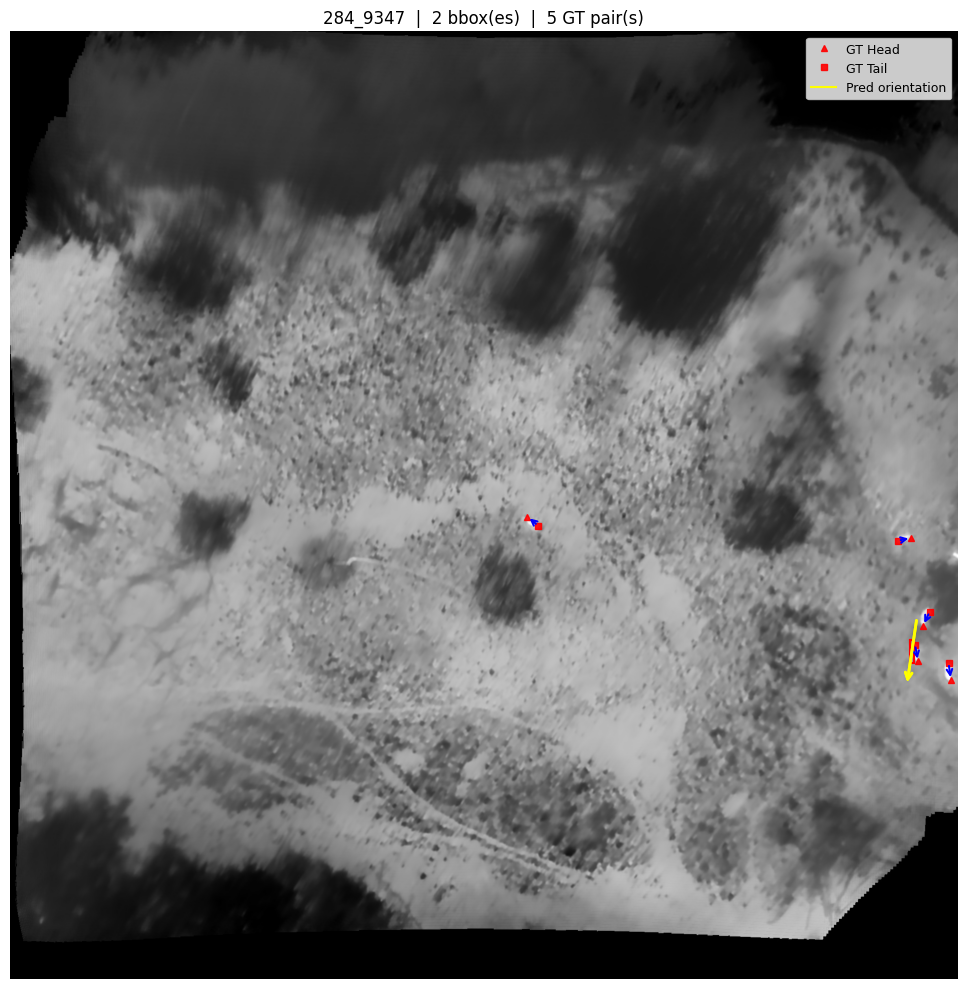

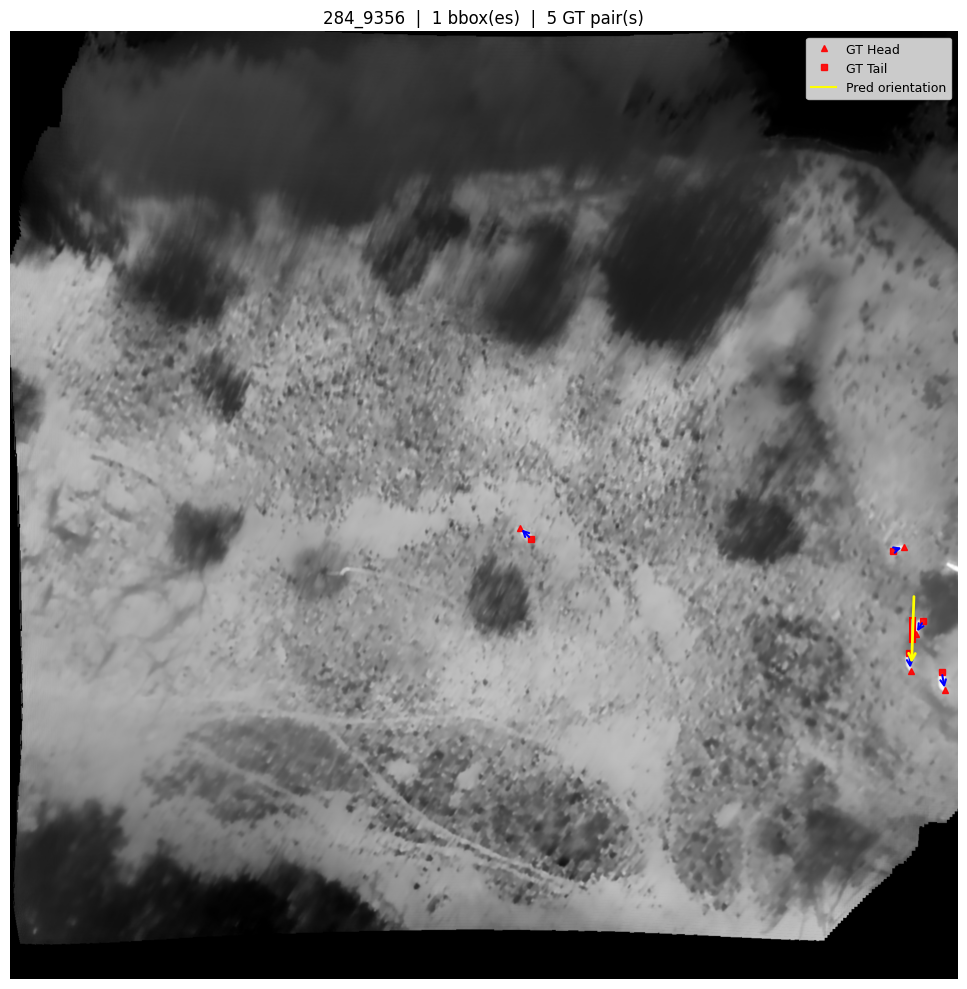

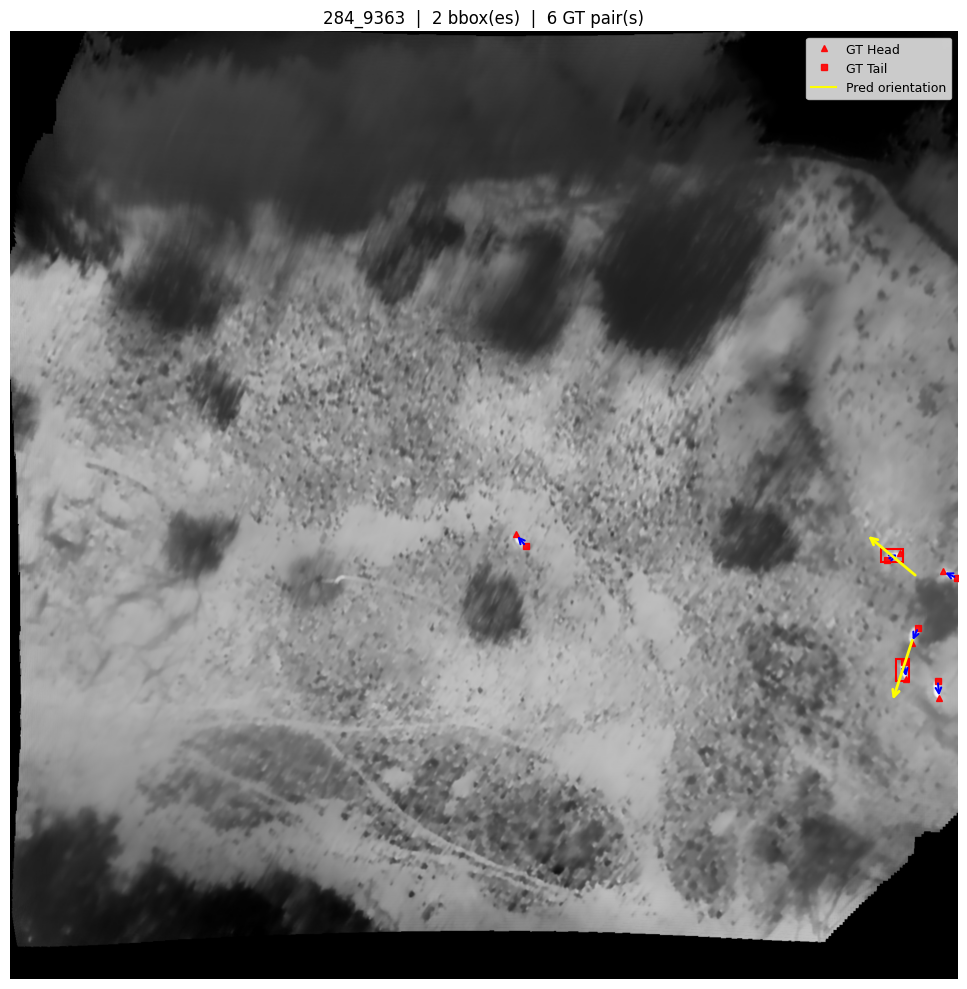

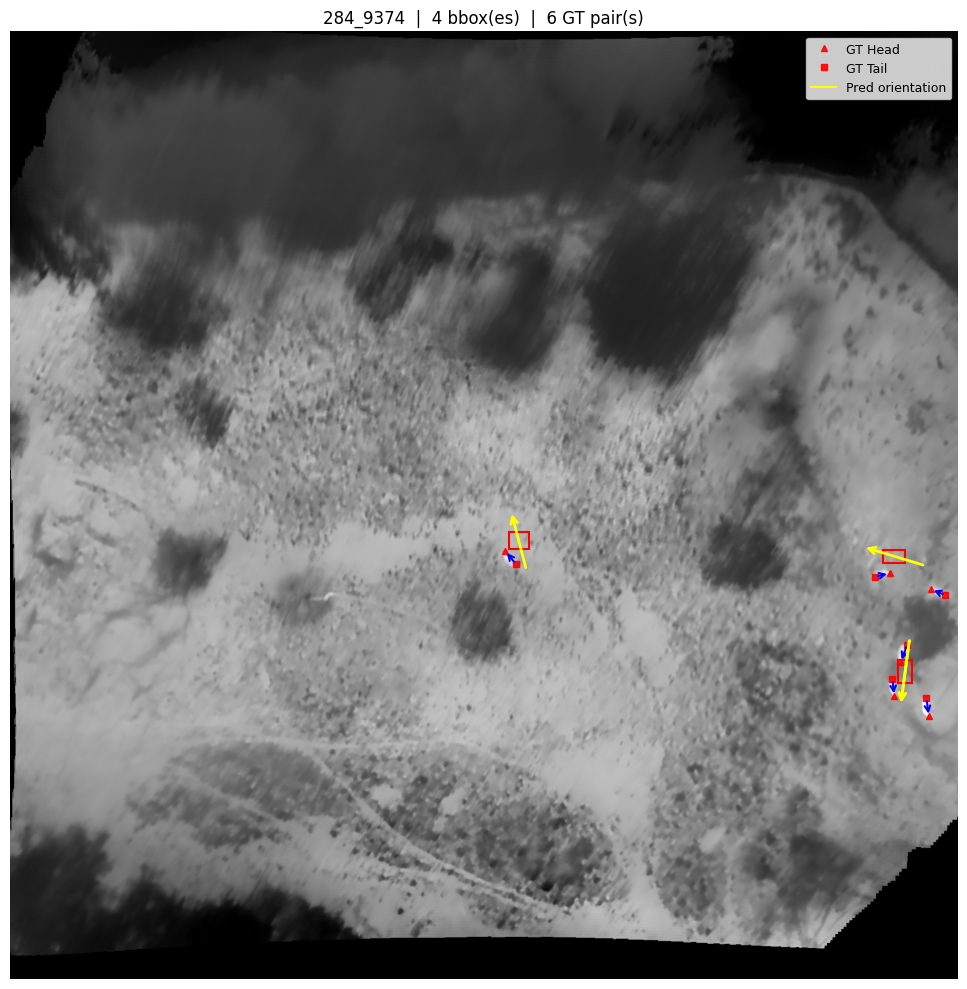

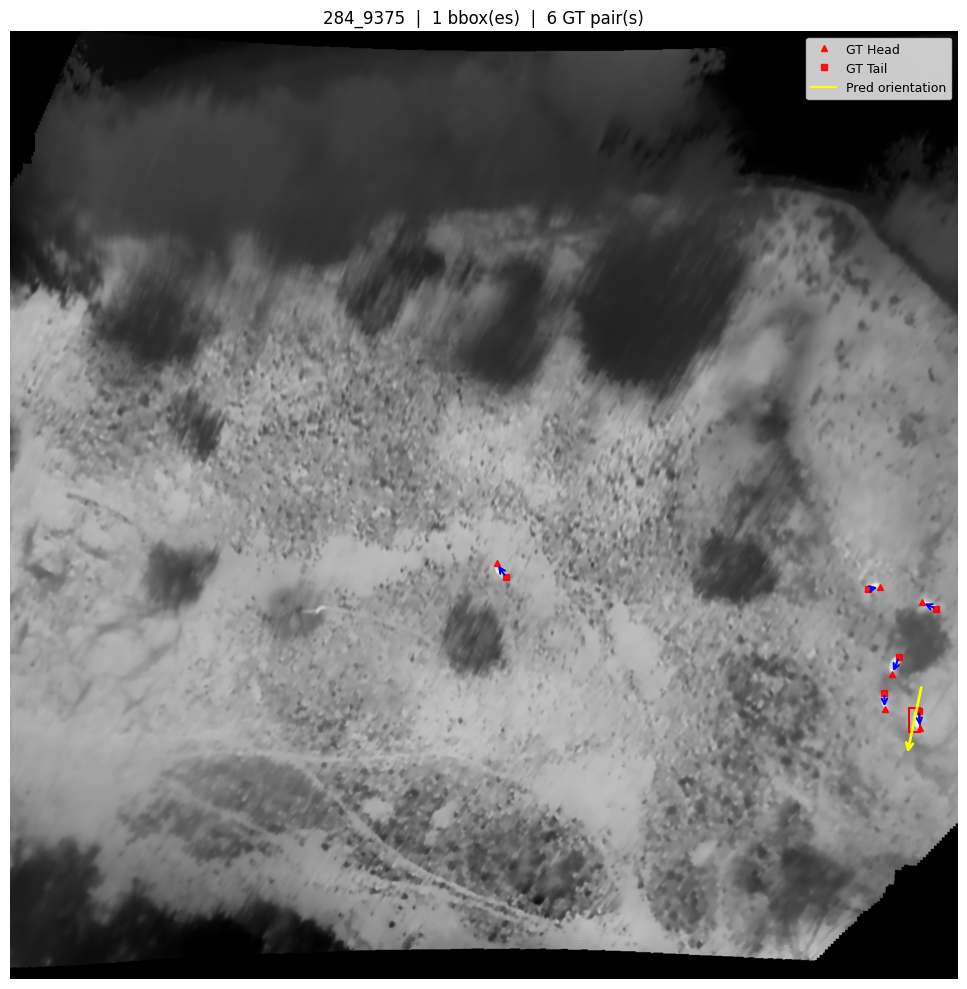

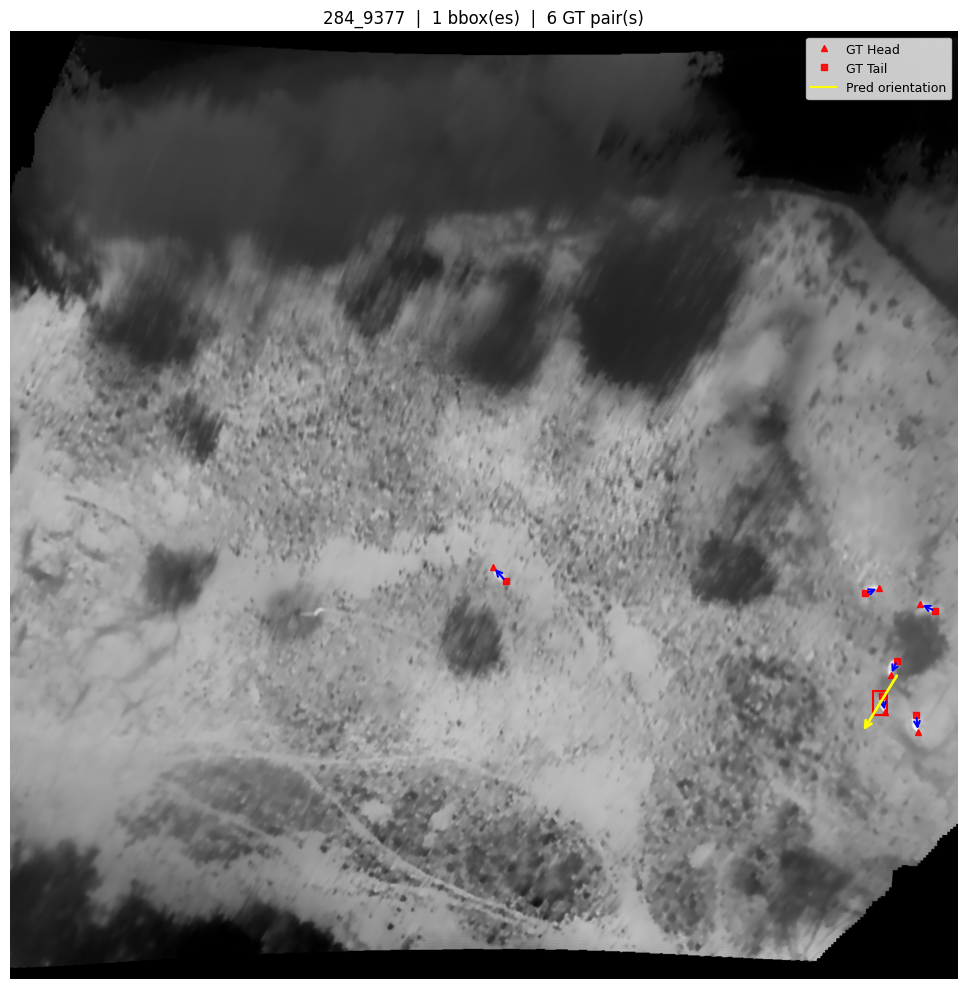

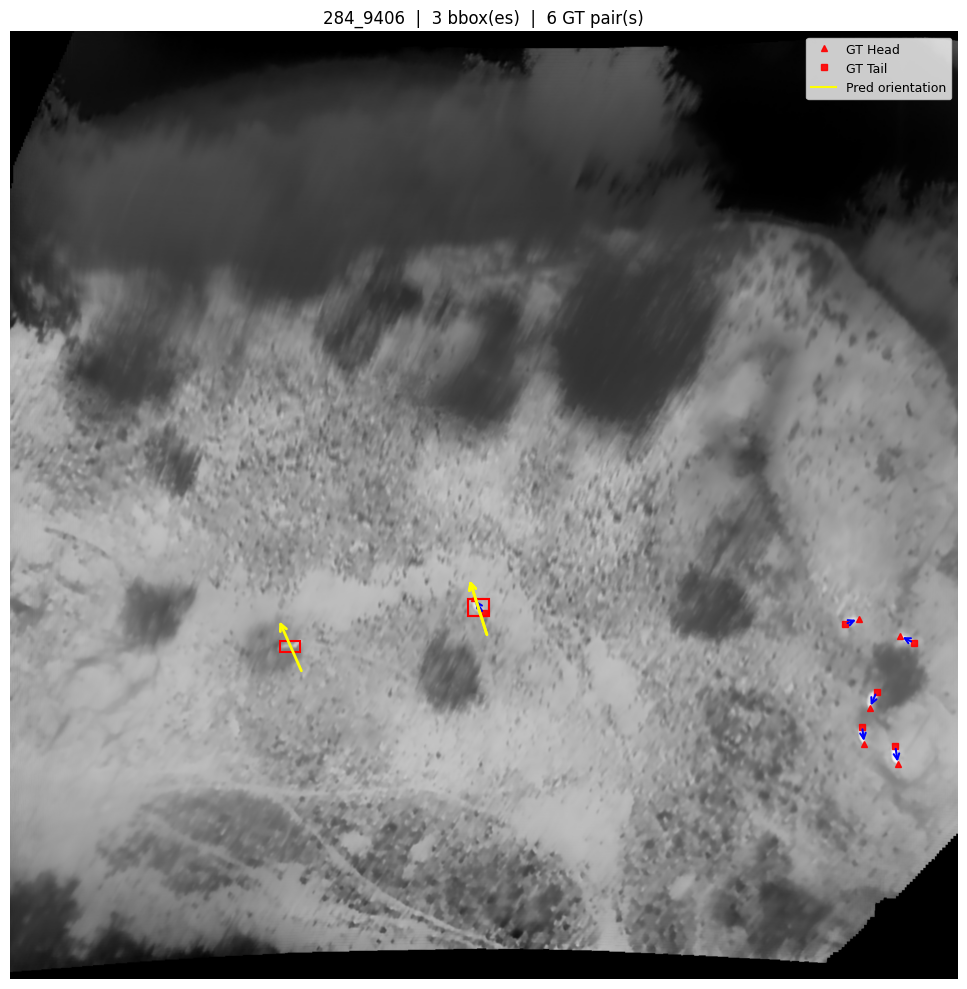

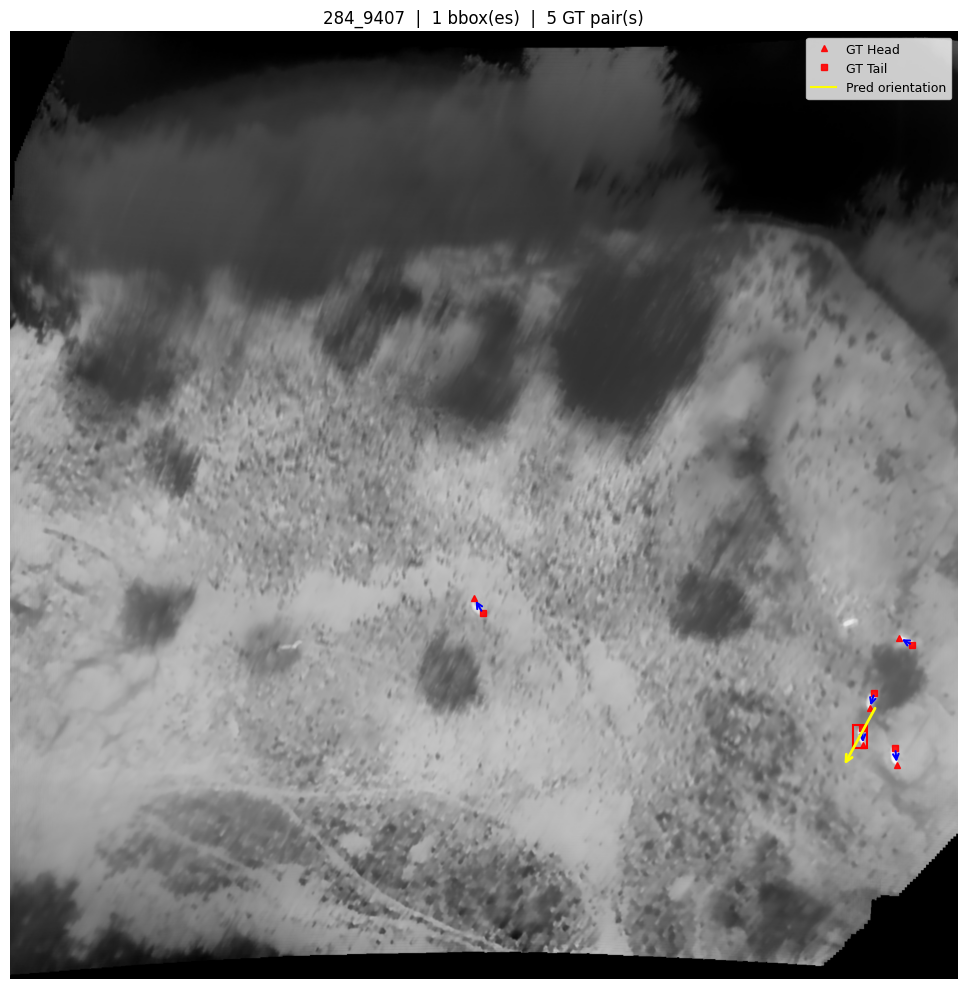

In [10]:
print("Visualizing sample predictions from test set:")
print("-" * 60)

# get all test images
test_images = sorted([f.stem for f in TEST_IMG.glob('*.jpg')])

# visualize first 8
for img_name, label_split in labeled[:8]:
    visualize_prediction(img_name, img_split='test', show_ground_truth=True)

## Batch Visualization


Batch visualization (8 images):


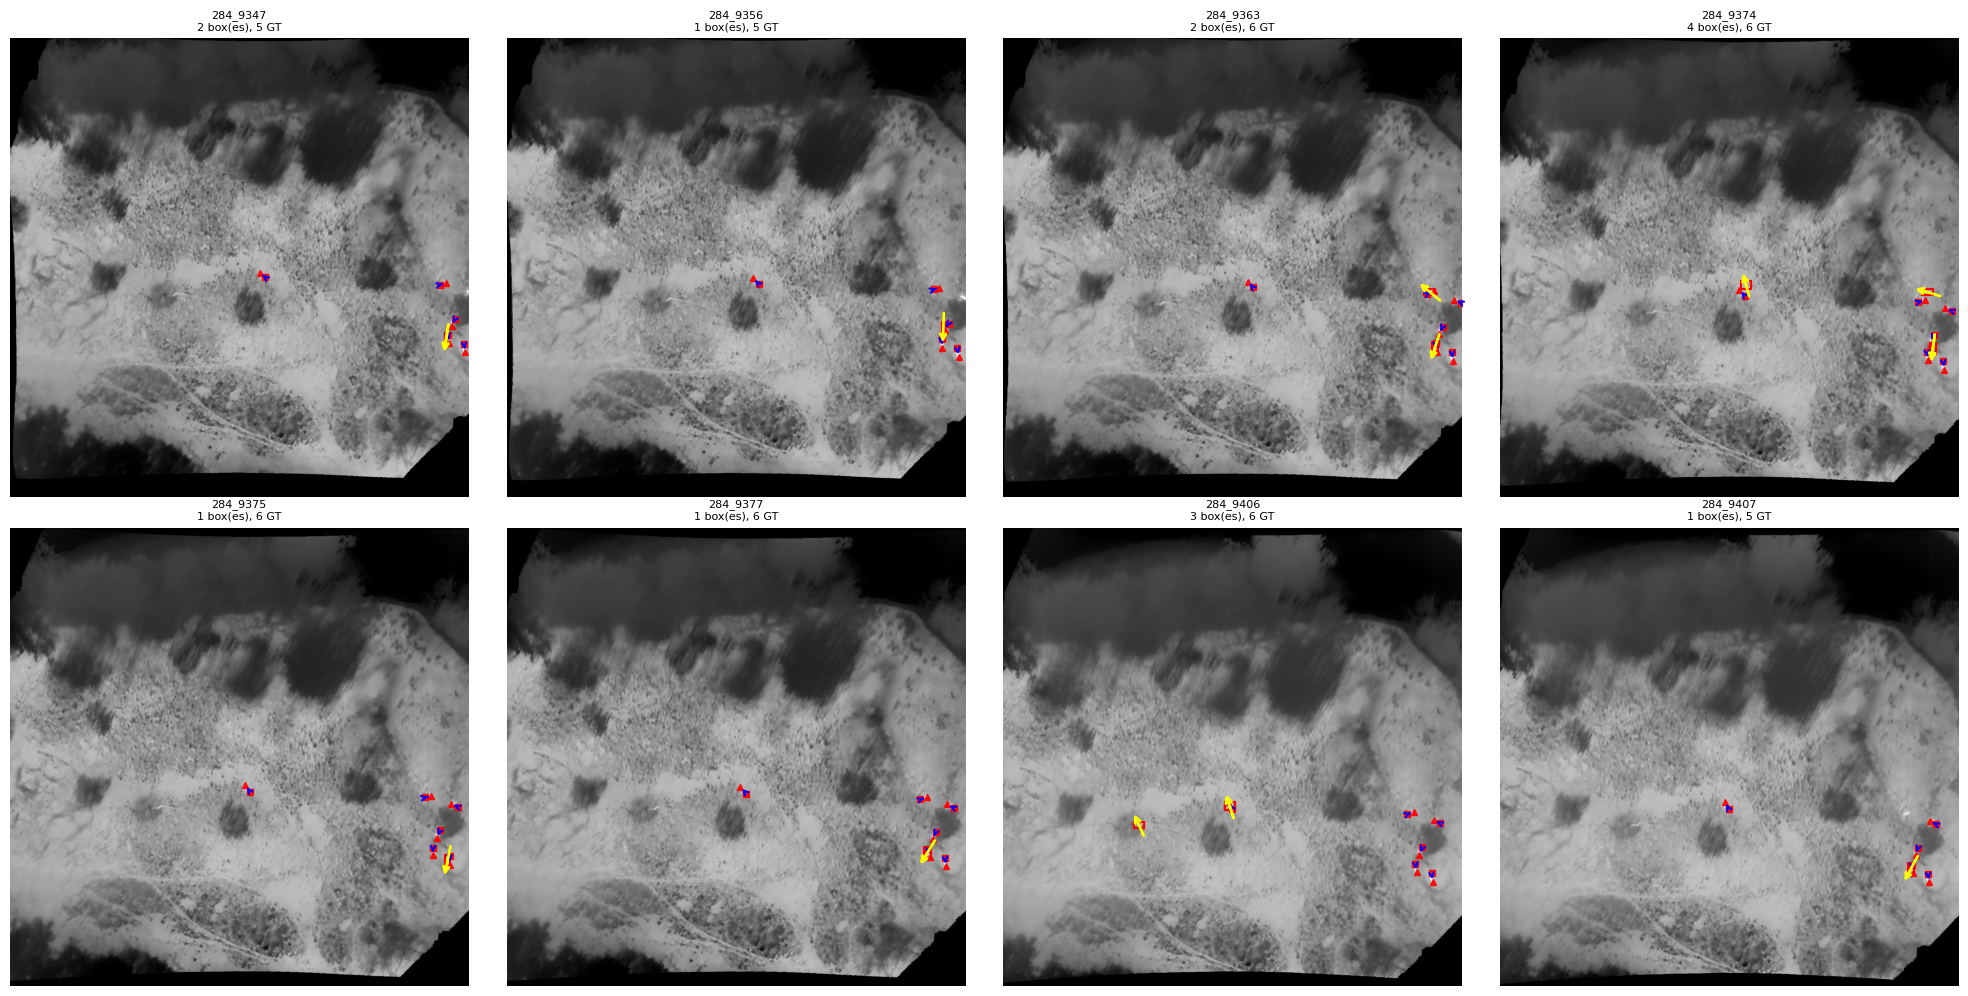

In [11]:
# visualize a batch of images in a grid, showing bboxes, GT pairs and predicted orientations
def visualize_batch(n_samples=8):
    batch_images = labeled[:n_samples]

    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    cols = 4
    rows = (len(batch_images) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten()

    for idx, (img_name, label_split) in enumerate(batch_images):
        img_path = TEST_IMG / f"{img_name}.jpg"
        kp_label_path = LABELS_DIR / label_split / f"{img_name}.txt"

        img = Image.open(img_path).convert('RGB')
        orig_w, orig_h = img.size

        bboxes = load_all_bboxes(kp_label_path)
        if not bboxes:
            continue

        predictions = []
        for bbox in bboxes:
            x1, y1, x2, y2 = compute_crop(bbox, orig_w, orig_h)
            cx_px = bbox['cx'] * orig_w
            cy_px = bbox['cy'] * orig_h
            img_crop = img.crop((x1, y1, x2, y2))
            img_tensor = transform(img_crop).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                out = model(img_tensor).cpu().numpy()[0]
            angle = np.arctan2(out[0], out[1])
            arrow_len = max(bbox['bw'] * orig_w, bbox['bh'] * orig_h) * 1.5
            predictions.append({
                'cx': cx_px, 'cy': cy_px,
                'angle': angle, 'arrow_len': arrow_len,
            })

        axes[idx].imshow(img)

        # draw bboxes
        for bbox in bboxes:
            cx, cy = bbox['cx'] * orig_w, bbox['cy'] * orig_h
            bw, bh = bbox['bw'] * orig_w, bbox['bh'] * orig_h
            rect = plt.Rectangle((cx - bw/2, cy - bh/2), bw, bh,
                                  fill=False, edgecolor='red', linewidth=1.5)
            axes[idx].add_patch(rect)

        # draw GT arrows
        if img_name in gt_lookup:
            for pair in gt_lookup[img_name]:
                gt_hx = pair['Head'][0] * orig_w
                gt_hy = pair['Head'][1] * orig_h
                gt_tx = pair['Tail'][0] * orig_w
                gt_ty = pair['Tail'][1] * orig_h
                axes[idx].annotate('', xy=(gt_hx, gt_hy), xytext=(gt_tx, gt_ty),
                                   arrowprops=dict(arrowstyle='->', color='blue',
                                                   lw=1.5, mutation_scale=8))
                axes[idx].plot(gt_hx, gt_hy, 'r^', markersize=4, alpha=0.9)
                axes[idx].plot(gt_tx, gt_ty, 'rs', markersize=4, alpha=0.9)

        # draw predicted orientation arrows
        for pred in predictions:
            dx = np.cos(pred['angle']) * pred['arrow_len']
            dy = np.sin(pred['angle']) * pred['arrow_len']
            axes[idx].annotate('', xy=(pred['cx'] + dx, pred['cy'] + dy),
                               xytext=(pred['cx'] - dx, pred['cy'] - dy),
                               arrowprops=dict(arrowstyle='->', color='yellow',
                                               lw=2, mutation_scale=10))

        n_gt = len(gt_lookup.get(img_name, []))
        axes[idx].axis('off')
        axes[idx].set_title(f"{img_name}\n{len(bboxes)} box(es), {n_gt} GT", fontsize=8)

    for idx in range(len(batch_images), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

print(f"\nBatch visualization ({min(8, len(labeled))} images):")
visualize_batch(min(8, len(labeled)))

## Orientation Vector Analysis


Analyzing orientation angles...


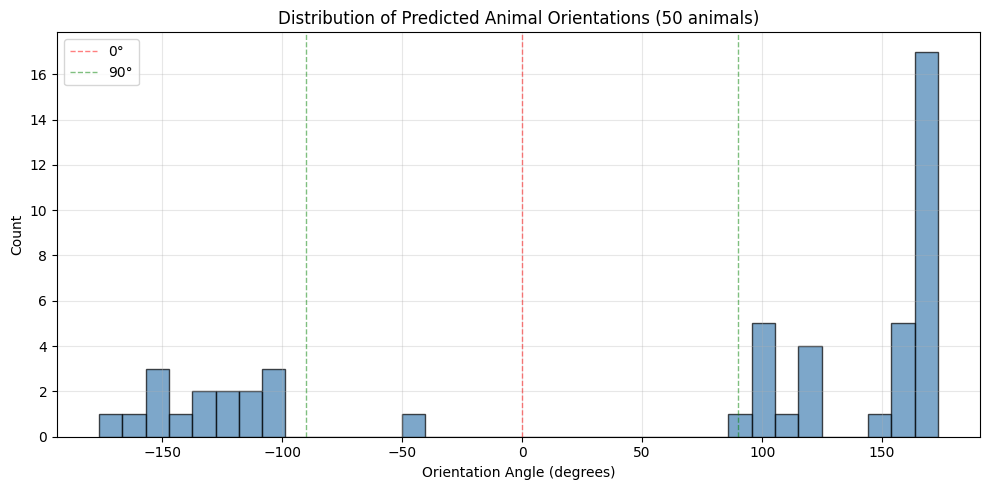

In [12]:
# compute orientation angles for all predicted animals in the test set
def get_orientation_angles(n_samples=None):
    images = labeled if n_samples is None else labeled[:n_samples]

    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    angles = []
    for img_name, label_split in images:
        img_path = TEST_IMG / f"{img_name}.jpg"
        kp_label_path = LABELS_DIR / label_split / f"{img_name}.txt"

        if not img_path.exists() or not kp_label_path.exists():
            continue

        img = Image.open(img_path).convert('RGB')
        orig_w, orig_h = img.size

        bboxes = load_all_bboxes(kp_label_path)
        for bbox in bboxes:
            x1, y1, x2, y2 = compute_crop(bbox, orig_w, orig_h)
            img_crop = img.crop((x1, y1, x2, y2))
            img_tensor = transform(img_crop).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                out = model(img_tensor).cpu().numpy()[0]
            angle_deg = np.degrees(np.arctan2(out[0], out[1]))
            angles.append(angle_deg)

    return angles

print("\nAnalyzing orientation angles...")
angles = get_orientation_angles(n_samples=min(50, len(labeled)))

plt.figure(figsize=(10, 5))
plt.hist(angles, bins=36, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Orientation Angle (degrees)')
plt.ylabel('Count')
plt.title(f'Distribution of Predicted Animal Orientations ({len(angles)} animals)')
plt.grid(True, alpha=0.3)
plt.axvline(x=0,   color='red',   linestyle='--', linewidth=1, alpha=0.5, label='0°')
plt.axvline(x=90,  color='green', linestyle='--', linewidth=1, alpha=0.5, label='90°')
plt.axvline(x=-90, color='green', linestyle='--', linewidth=1, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Summary
- Yellow arrows indicate the predicted orientation/direction the animal is facing
- The model provides reasonable estimates of animal orientation in thermal images